# 📈 3. Modelado: Regresión Lineal

En esta etapa se construyen modelos de regresión lineal para predecir el precio de venta de las viviendas (`SalePrice`) utilizando el dataset **Ames Housing**.

Se analizarán dos enfoques: una **regresión lineal simple**, empleando una única variable predictora, y una **regresión lineal múltiple**, incorporando varias variables explicativas según el dataset modificado en la notebook n° 2.

Finalmente, se comparará el desempeño de ambos modelos mediante distintas métricas de evaluación.

In [3]:
# Library
import pandas as pd
import matplotlib.pyplot as plt
import datetime as dt
import numpy as np
import scipy.stats
from sklearn.metrics import mean_squared_error, mean_absolute_error,r2_score
from math import sqrt
import os
from os import listdir
from datetime import datetime
import pandas as pd
from matplotlib.dates import DateFormatter
import matplotlib.ticker as ticker
import matplotlib.dates as mdates
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split,cross_val_score
import seaborn as sns
import plotly.express as px
import kagglehub
import os
print ("librerias ok")

librerias ok


In [4]:
# Directorio actual
print(os.getcwd())

d:\Josefina\Proyectos\Datascience\Curso_ML\Modelos_ML\housing-price-analysis


In [45]:
# Leemos el dataset generado anteriormente
df = pd.read_csv("../data/AmesHousing_modificado.csv")
print(df.shape) #Quedaron menos columnas pero igual son bastantes
df.head(5)


(2930, 23)


,Unnamed: 0,SalePrice,Overall Qual,Gr Liv Area,Total Bsmt SF,Garage Area,Year Built,Year Remod/Add,Full Bath,Mas Vnr Area,...,Wood Deck SF,Open Porch SF,Neighborhood,Kitchen Qual,Exter Qual,Bsmt Qual,Garage Finish,Foundation,House Style,Sale Condition
0,0,215000,6,1656,1080.0,528.0,1960,1960,1,112.0,...,210,62,NAmes,TA,TA,TA,Fin,CBlock,1Story,Normal
1,1,105000,5,896,882.0,730.0,1961,1961,1,0.0,...,140,0,NAmes,TA,TA,TA,Unf,CBlock,1Story,Normal
2,2,172000,6,1329,1329.0,312.0,1958,1958,1,108.0,...,393,36,NAmes,Gd,TA,TA,Unf,CBlock,1Story,Normal
3,3,244000,7,2110,2110.0,522.0,1968,1968,2,0.0,...,0,0,NAmes,Ex,Gd,TA,Fin,CBlock,1Story,Normal
4,4,189900,5,1629,928.0,482.0,1997,1998,2,0.0,...,212,34,Gilbert,TA,TA,Gd,Fin,PConc,2Story,Normal


In [21]:
df['Mas Vnr Area'].describe()
# df.columns


count    2907.000000
mean      101.896801
std       179.112611
min         0.000000
25%         0.000000
50%         0.000000
75%       164.000000
max      1600.000000
Name: Mas Vnr Area, dtype: float64

In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 23 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      2930 non-null   int64  
 1   SalePrice       2930 non-null   int64  
 2   Overall Qual    2930 non-null   int64  
 3   Gr Liv Area     2930 non-null   int64  
 4   Total Bsmt SF   2929 non-null   float64
 5   Garage Area     2929 non-null   float64
 6   Year Built      2930 non-null   int64  
 7   Year Remod/Add  2930 non-null   int64  
 8   Full Bath       2930 non-null   int64  
 9   Mas Vnr Area    2907 non-null   float64
 10  Fireplaces      2930 non-null   int64  
 11  Lot Area        2930 non-null   int64  
 12  Lot Frontage    2440 non-null   float64
 13  Wood Deck SF    2930 non-null   int64  
 14  Open Porch SF   2930 non-null   int64  
 15  Neighborhood    2930 non-null   str    
 16  Kitchen Qual    2930 non-null   str    
 17  Exter Qual      2930 non-null   str    
 18 

In [46]:
#Hacemos una copia para trabajar menjor
df_model = df.copy()

In [ ]:
#Volvemos a corroborar los nulls
df_model.isnull().sum()

Unnamed: 0          0
SalePrice           0
Overall Qual        0
Gr Liv Area         0
Total Bsmt SF       1
Garage Area         1
Year Built          0
Year Remod/Add      0
Full Bath           0
Mas Vnr Area       23
Fireplaces          0
Lot Area            0
Lot Frontage      490
Wood Deck SF        0
Open Porch SF       0
Neighborhood        0
Kitchen Qual        0
Exter Qual          0
Bsmt Qual          80
Garage Finish     159
Foundation          0
House Style         0
Sale Condition      0
dtype: int64

In [ ]:
# Eliminar NA (o imputar después)
# df_model = df_model.dropna()

In [47]:
# Vamos con los nulos variable por variable
# 01. Total Bsmt SF hay 1 solo nulo, lo imputamos con la mediana porque hay un solo caso
df_model["Total Bsmt SF"] = df_model["Total Bsmt SF"].fillna(df_model["Total Bsmt SF"].median())

#02. Garage Area hay 1 solo nulo, lo imputamos con la mediana porque hay un solo caso
df_model["Garage Area"] = df_model["Garage Area"].fillna(df_model["Garage Area"].median())

#03. Mas Vnr Area imputar con 
df_model["Mas Vnr Area"] = df_model["Mas Vnr Area"].fillna(0)

#04. Lot Frontage imputar con la mediana (idealmente por Neighborhood)
#df_model["Lot Frontage"] = (df_model.groupby("Neighborhood")["Lot Frontage"].transform(lambda x: x.fillna(x.median())))
df_model["Lot Frontage"] = df_model["Lot Frontage"].fillna(df_model["Lot Frontage"].median())

# # 05. Bsmt Qual se reemplazar por "No Basement"
df_model["Bsmt Qual"].unique() #['TA', 'Gd', 'Ex', nan, 'Fa', 'Po']
df_model["Bsmt Qual"] = df_model["Bsmt Qual"].fillna("nan")
# # 06. Garage Finish Reemplazar por "No Garage"
df_model["Garage Finish"].unique() #['Fin', 'Unf', 'RFn', nan]
df_model["Garage Finish"] = df_model["Garage Finish"].fillna("nan")

#Volvemos a corroborar los nulls
df_model.isnull().sum()

# df_model = df_model.dropna()

Unnamed: 0        0
SalePrice         0
Overall Qual      0
Gr Liv Area       0
Total Bsmt SF     0
Garage Area       0
Year Built        0
Year Remod/Add    0
Full Bath         0
Mas Vnr Area      0
Fireplaces        0
Lot Area          0
Lot Frontage      0
Wood Deck SF      0
Open Porch SF     0
Neighborhood      0
Kitchen Qual      0
Exter Qual        0
Bsmt Qual         0
Garage Finish     0
Foundation        0
House Style       0
Sale Condition    0
dtype: int64

In [48]:
# Pasar las variables categoricas a numericas de alguna forma
mapping_Kitchen = {"Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5 }
df_model["Kitchen Qual"] = df_model["Kitchen Qual"].map(mapping_Kitchen)

mapping_exter = {"Fa": 1, "TA": 2, "Gd": 3, "Ex": 4}
df_model["Exter Qual"] = df_model["Exter Qual"].map(mapping_exter)

mapping_Bsmt = {"Po": 1,"Fa": 2,"TA": 3,"Gd": 4,"Ex": 5}
df_model["Bsmt Qual"] = df_model["Bsmt Qual"].map(mapping_Bsmt)

# One-Hot Encoding porque no hay un orden en ellas
df_model = pd.get_dummies(df_model, columns=["House Style"], drop_first=True)

df_model = pd.get_dummies(df_model, columns=["Foundation"], drop_first=True)
mapping_garage = {"Unf": 1, "RFn": 2, "Fin": 3 }
df_model["Garage Finish"] = df_model["Garage Finish"].map(mapping_garage)

df_model = pd.get_dummies(df_model, columns = ["Sale Condition"], drop_first = True, dtype=int)
df_model = pd.get_dummies(df_model, columns = ["Neighborhood"], drop_first = True, dtype = int)

df_model = df_model.dropna()

In [49]:
#Lo guardamos para usarlo en los modelos restantes
df_model.to_csv("../data/AmesHousing_modificado_RL.csv")

In [ ]:

# Variable objetivo
y = df_model["SalePrice"]

# Variables predictoras
X = df_model.drop(columns="SalePrice")


print(f"Cantidad de observaciones: {len(df_model)}")
print(f"Número de variables predictoras: {X.shape[1]}")

X.head()

Cantidad de observaciones: 2705
Número de variables predictoras: 63


,Unnamed: 0,Overall Qual,Gr Liv Area,Total Bsmt SF,Garage Area,Year Built,Year Remod/Add,Full Bath,Mas Vnr Area,Fireplaces,...,Neighborhood_NoRidge,Neighborhood_NridgHt,Neighborhood_OldTown,Neighborhood_SWISU,Neighborhood_Sawyer,Neighborhood_SawyerW,Neighborhood_Somerst,Neighborhood_StoneBr,Neighborhood_Timber,Neighborhood_Veenker
0,0,6,1656,1080.0,528.0,1960,1960,1,112.0,2,...,0,0,0,0,0,0,0,0,0,0
1,1,5,896,882.0,730.0,1961,1961,1,0.0,0,...,0,0,0,0,0,0,0,0,0,0
2,2,6,1329,1329.0,312.0,1958,1958,1,108.0,0,...,0,0,0,0,0,0,0,0,0,0
3,3,7,2110,2110.0,522.0,1968,1968,2,0.0,2,...,0,0,0,0,0,0,0,0,0,0
4,4,5,1629,928.0,482.0,1997,1998,2,0.0,1,...,0,0,0,0,0,0,0,0,0,0


In [37]:
df_model.info()

<class 'pandas.DataFrame'>
Index: 2705 entries, 0 to 2929
Data columns (total 64 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Unnamed: 0              2705 non-null   int64  
 1   SalePrice               2705 non-null   int64  
 2   Overall Qual            2705 non-null   int64  
 3   Gr Liv Area             2705 non-null   int64  
 4   Total Bsmt SF           2705 non-null   float64
 5   Garage Area             2705 non-null   float64
 6   Year Built              2705 non-null   int64  
 7   Year Remod/Add          2705 non-null   int64  
 8   Full Bath               2705 non-null   int64  
 9   Mas Vnr Area            2705 non-null   float64
 10  Fireplaces              2705 non-null   int64  
 11  Lot Area                2705 non-null   int64  
 12  Lot Frontage            2705 non-null   float64
 13  Wood Deck SF            2705 non-null   int64  
 14  Open Porch SF           2705 non-null   int64  
 15  Kit

In [38]:
#Ahora si vamos a dividir
# Entrenamiento 80% - 20% testeo
# random_state, es una semilla aleatorio
X_Train,X_Test, Y_Train,Y_Test = train_test_split(X, y, test_size = 0.2, random_state = 42)

#Veo la longitud
print(f"Datos para entrenar {X_Train.shape[0]} pasajeros")
print(f"Datos para testear {X_Test.shape[0]} pasajeros")

Datos para entrenar 2164 pasajeros
Datos para testear 541 pasajeros


In [39]:
#Entrenar modelo
#Genero el modelo
modelo = LinearRegression ()

#Entreno el modelo con mis datos
modelo.fit(X_Train, Y_Train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [40]:
# Ahora hay que hacer la prediccion porque el modelo ya esta entrenado
predicciones_train = modelo.predict(X_Train) #visto por el modelo original
predicciones_test = modelo.predict(X_Test) #no visto por el modelo original

In [41]:
# Calculamos metricas estadisticas
#Se calcula el Error Absoluto Medio
mae_train = mean_absolute_error (Y_Train, predicciones_train)
mae_test = mean_absolute_error (Y_Test, predicciones_test)

#Calcular r2 (que porcentaje del problema se entendio)
r2_train = r2_score(Y_Train, predicciones_train)
r2_test = r2_score(Y_Test, predicciones_test)


#Calcular RMSE: con la raiz cuadrada del MSE
rmse_train =np.sqrt(mean_squared_error(Y_Train, predicciones_train))
rmse_test =np.sqrt(mean_squared_error(Y_Test, predicciones_test))


### Hacer print para ver las metricas
print(f"Error promedio del train: {round(mae_train,2)}") # se esta equivocando el boleto en $24.3
print(f"Error promedio del test: {round(mae_test,2)}") # se esta equivocando el boleto en $24.85

#Error cuadtatico medio. En general tiene que dar mas grande
print(f"RMSE train: {round(rmse_train,2)}") # se esta equivocando el boleto en $43.45
print(f"RMSE test: {round(rmse_test,2)}")  # se esta equivocando el boleto en $45.3, el modelo esta pifiando bastante


print(f"R2 train: {round(r2_train,2)}")
print(f"R2 test: {round(r2_test,2)}")



Error promedio del train: 19134.34
Error promedio del test: 21067.33
RMSE train: 30312.47
RMSE test: 34457.64
R2 train: 0.85
R2 test: 0.83


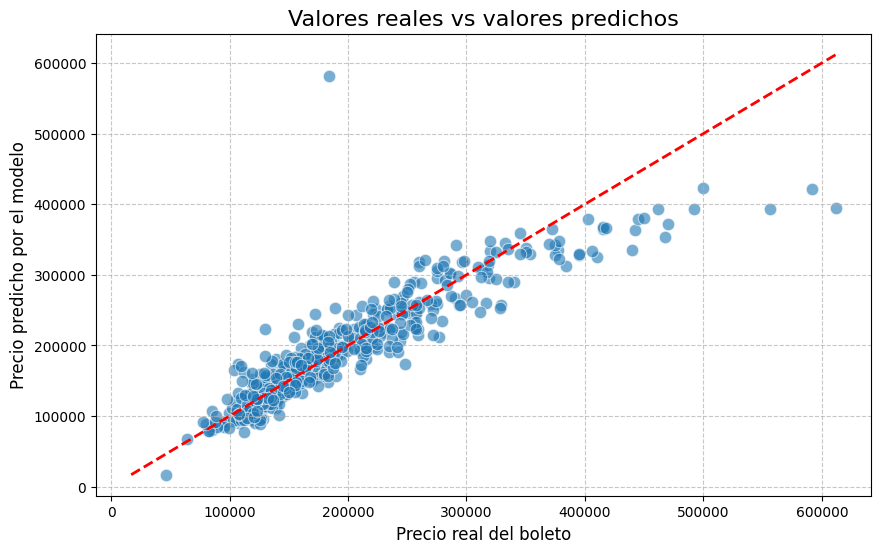

In [42]:

# Gráfico de evaluación del modelo: valores reales vs valores predichos
# Este gráfico permite evaluar visualmente el desempeño del modelo de regresión.
# Cada punto representa una observación del conjunto de prueba.
# Cuanto más cerca se encuentren los puntos de la línea diagonal (y = x),
# menor será el error de predicción.


# Convertir las estructuras de datos a vectores unidimensionales para facilitar
# su visualización.
y_real = Y_Test.squeeze()
y_pred = predicciones_test.flatten()

# Plot
plt.figure(figsize=(10, 6))

#Valores reales VS los valores predichos
sns.scatterplot(
    x=y_real,
    y=y_pred,
    alpha=0.6,  # Transparencia para mejorar la visualización
    s=80        # Tamaño de los puntos
)

# Calcular los límites del gráfico considerando ambos conjuntos de datos.
# Esto garantiza que la línea de referencia cubra todo el rango observado.
min_val = min(y_real.min(), y_pred.min())
max_val = max(y_real.max(), y_pred.max())

# Dibujar la línea de referencia 1:1
# Los puntos ubicados sobre esta línea representan predicciones exactas.
plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    color="red",
    linestyle="--",
    linewidth=2
)

# Configuración estética del gráfico
plt.title("Valores reales vs valores predichos", fontsize=16)
plt.xlabel("Precio real del boleto", fontsize=12)
plt.ylabel("Precio predicho por el modelo", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.7)

# Mostrar gráfico
plt.show()